# Data exploration

In [ ]:
%load_ext autoreload
%autoreload 2

from ml4cv_assignment.config.config import Config
from ml4cv_assignment.data.data_analysis import (
    analyze_dataset,
    browse_dataset,
    compute_class_heatmap,
    plot_class_counts,
    plot_class_heatmaps,
    plot_rgb_means,
)
from ml4cv_assignment.utils.misc import get_id_to_label_map

cfg = Config.load("../configs/base.yaml")

train_ds = cfg.train_dataset
val_ds = cfg.val_dataset

print(f"Number of training images: {len(train_ds)}")
print(f"Number of validation images: {len(val_ds)}")

2025-11-09 15:29:31.154 | INFO     | ml4cv_assignment.data.torch_serialized_list:__init__:43 - Serialized dataset takes 0.00 MiB
2025-11-09 15:29:31.188 | INFO     | ml4cv_assignment.data.torch_serialized_list:__init__:43 - Serialized dataset takes 0.00 MiB
2025-11-09 15:29:31.193 | INFO     | ml4cv_assignment.data.torch_serialized_list:__init__:43 - Serialized dataset takes 0.00 MiB
2025-11-09 15:29:31.197 | INFO     | ml4cv_assignment.data.torch_serialized_list:__init__:43 - Serialized dataset takes 0.00 MiB


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of training images: 5125
Number of validation images: 1031


In [43]:
train_ds_stats = analyze_dataset(train_ds)
val_ds_stats = analyze_dataset(val_ds)

Analyzing dataset: 100%|██████████| 1031/1031 [00:58<00:00, 17.68img/s]


In [3]:
print(f"Image sizes in train set: {train_ds_stats.image_sizes}")
print(f"Image sizes in val set: {val_ds_stats.image_sizes}")

Image sizes in train set: {(720, 1280)}
Image sizes in val set: {(720, 1280)}


The images in the training and validation sets have the **same size**; however, their format is **rectangular rather than square**.
Since most pretrained models are trained on square-shaped inputs (e.g., 224x224), maintaining a consistent input shape with the original training setup is important.

Simply resizing the rectangular images to a square format could introduce **distortion**, potentially altering object proportions and affecting model performance.

A possible solution is to apply **letterbox padding** to make the images square without distortion.
Alternatively, the inconsistent dimensions can be ignored, and the images can be fed to the model in their rectangular format, provided the architecture supports variable input sizes.

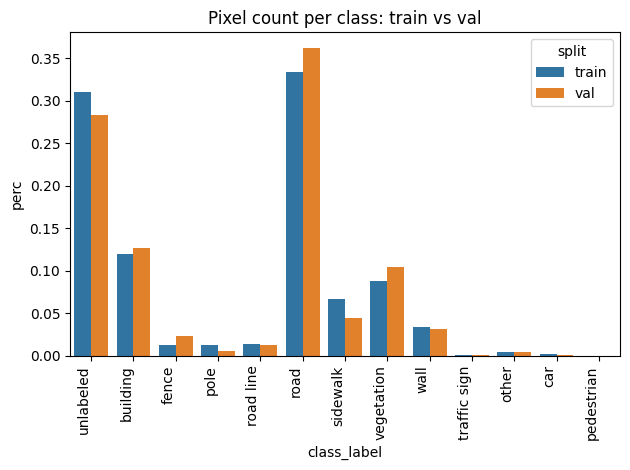

In [4]:
id_to_label_map = get_id_to_label_map()
plot_class_counts(
    train_ds_stats.pixel_counts, val_ds_stats.pixel_counts, id_to_label_map, "Pixel"
)

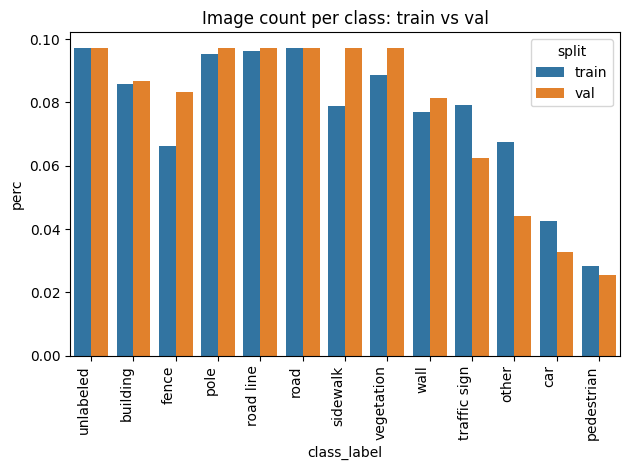

In [5]:
plot_class_counts(
    train_ds_stats.image_counts, val_ds_stats.image_counts, id_to_label_map, "Image"
)

The pixel count and image count distributions between the training and validation sets are overall similar, indicating that the two splits are consistent in termn of class representation.

However, the **pixel count distribution reveals a strong class imbalance**.  This is likely due to both the **size of objects** in the images and their **lower frequency of occurrence**. For example, classes like _road_ and _unlabeled_ (sky) cover large portions of the frame, while smaller objects such as _traffic signs_ and _pedestrians_ occupy fewer pixels and appear in fewer images.

This imbalance suggest the benefit of using focal loss or class weighting strategies during training to mitigate the bias toward majority classes.

In [12]:
print("Training set mean per channel (R, G, B):", train_ds_stats.rgb_means.mean(axis=0))
print("Training set std per channel (R, G, B):", train_ds_stats.rgb_stds.mean(axis=0))
print("Validation set mean per channel (R, G, B):", val_ds_stats.rgb_means.mean(axis=0))
print("Validation set std per channel (R, G, B):", val_ds_stats.rgb_stds.mean(axis=0))

Training set mean per channel (R, G, B): [0.3307164  0.34626445 0.37320235]
Training set std per channel (R, G, B): [0.1615142  0.15994391 0.17404957]
Validation set mean per channel (R, G, B): [0.33165857 0.34048793 0.35836303]
Validation set std per channel (R, G, B): [0.16222227 0.15592927 0.16400203]


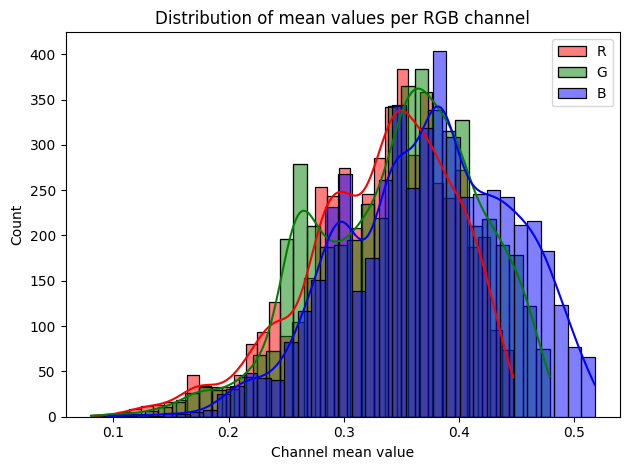

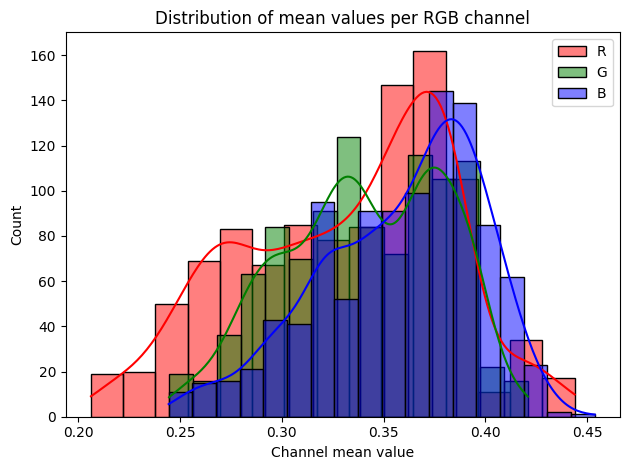

In [21]:
plot_rgb_means(train_ds_stats.rgb_means)
plot_rgb_means(val_ds_stats.rgb_means)

The fact that all values are below 0.5 suggests that the images contain **predominantly gray regions**, which is consistent with a street-driving dataset due to the **strong presence of asphalt and buildings**.

The **higher presence of blue likely indicates many areas of sky**, which is also in line with an street-driving dataset.

Both the training and validation sets show similar color distributions, as well as comparable dynamic variation.

The distributions are **mesocurtic**, showing significant variance. This suggests that the dataset contains images with a wide range of lighting conditions, from bright scenes under direct sunlight to darker scenes in shadow or on cloudy days.

In the validation set, the green (G) channel distribution is **shifted to the right** relative to the red (R) channel, whereas in the training set they were nearly overlapping, suggesting a potential **data shift**.

In [26]:
train_class_heatmap = compute_class_heatmap(train_ds)
val_class_heatmap = compute_class_heatmap(val_ds)

Computing heatmap: 100%|██████████| 1031/1031 [00:26<00:00, 38.32img/s]


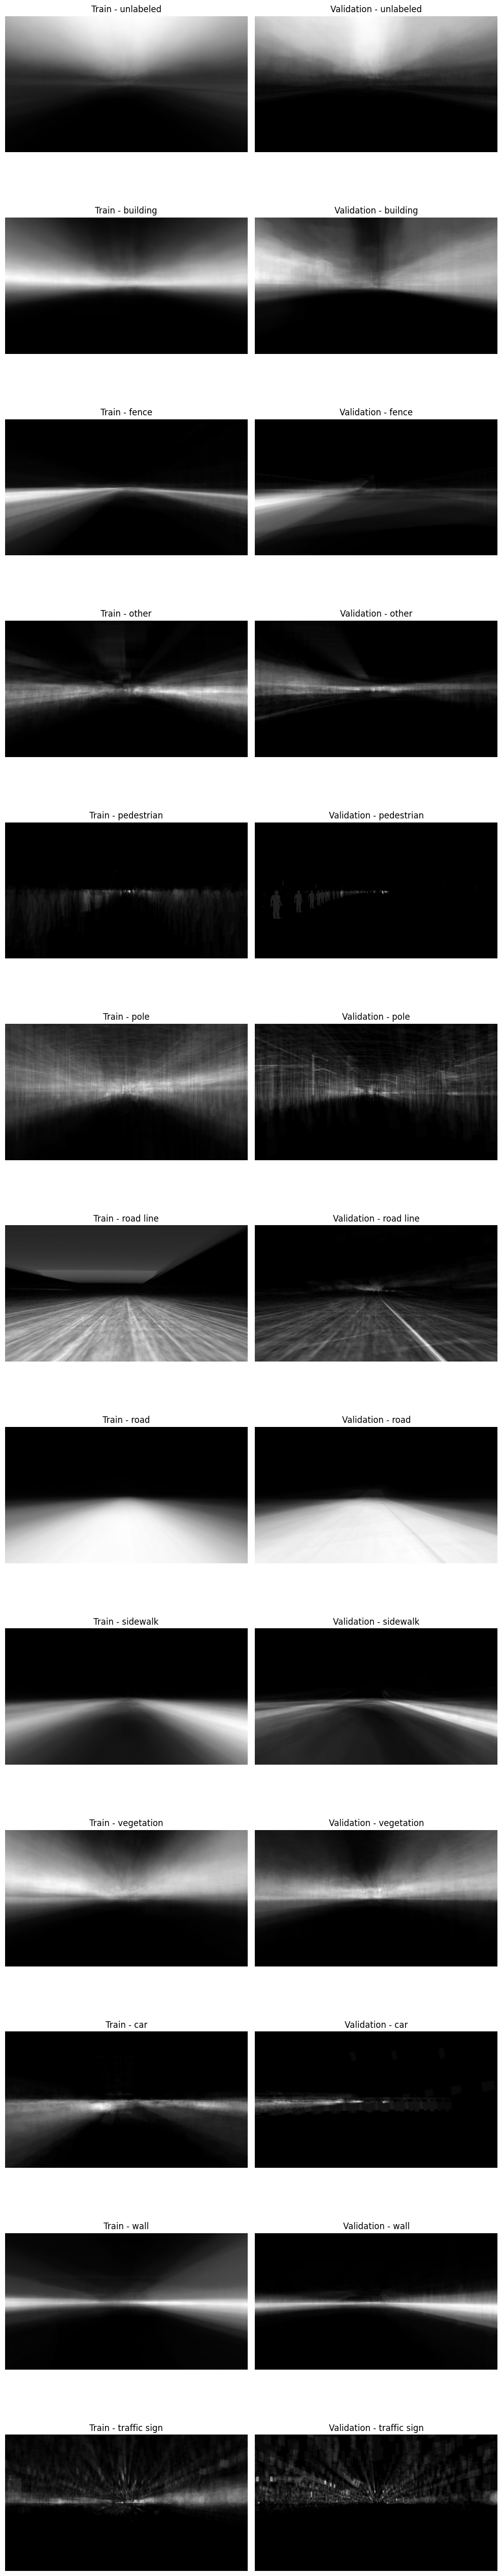

In [38]:
plot_class_heatmaps(train_class_heatmap, val_class_heatmap, id_to_label_map)

Those are the spatial distributions of each class calculated over all images of the training and validation datasets. Brighter areas indicate a higher frequency of appearance.

Some objects consistently appear in certain parts of the images: the sky is always at the top, the road is always at the bottom, sidewalks and pedestrians are on or alongside the road (they don't float in the sky). Cars are on the road, and so on.

Attention is therefore needed when applying geometric data augmentation so as
**not to break the "world rules"**, preserving these useful spatial biases and avoiding negative impacts on model performance.

If the spatial priors between training and validation were not aligned, more aggressive data augmentation could have been applied.

In [40]:
browse_dataset(train_ds)

interactive(children=(IntSlider(value=0, description='Index:', max=5124), Output()), _dom_classes=('widget-int…

In [41]:
browse_dataset(val_ds)

interactive(children=(IntSlider(value=0, description='Index:', max=1030), Output()), _dom_classes=('widget-int…

The dataset shows **significant variability in weather conditions**, including sunny and rainy days. As a result, it contains challenging situations such as reflections, glare, and variations in color distribution during sunrise and sunset, which could suggest the use of data augmentations to handle these situations and improve generalization.

Moreover, the dataset contains **sequential frames**, which can impact the model due to dependencies between samples in a batch, suggesting the need to shuffle the training set.

Finally, there is some **ambiguity** in the labeling. For example, some objects belonging to buildings or other structures end up in the **"unlabeled" category along with the sky**. This ambiguity could affect the model, as similar pixels may have different labels (e.g., one building labeled correctly and another considered unlabeled).
